# yfinanceの使い方
[クイックスタート](https://ranaroussi.github.io/yfinance/)

- 要件定義のデータ一覧、取得元カラムを作成する

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st

print("yfinance version:", yf.__version__)

yfinance version: 1.2.0


In [2]:
# データ取得の基礎
ticker = yf.Ticker("9531.T")  # 東京ガス

# hist
アプリ開発Ver1は、株価チャートに関する機能を開発する。

そのためのPoCとして、`history`で取整理する得できる情報を整理する

In [3]:
hist = ticker.history(period="5y")
print(hist.shape)
hist.head()

(1222, 7)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-06-02 00:00:00+09:00,1884.437255,1893.376710,1857.618888,1888.906982,2533800,0.0,0.0
2021-06-03 00:00:00+09:00,1893.376585,1920.194950,1890.694748,1902.316040,1376300,0.0,0.0
2021-06-04 00:00:00+09:00,1888.459791,1890.247682,1873.709691,1883.543091,1808300,0.0,0.0
2021-06-07 00:00:00+09:00,1876.391576,1887.118922,1873.709740,1881.755249,1359600,0.0,0.0
2021-06-08 00:00:00+09:00,1873.709902,1911.255616,1873.262929,1909.020752,1391100,0.0,0.0


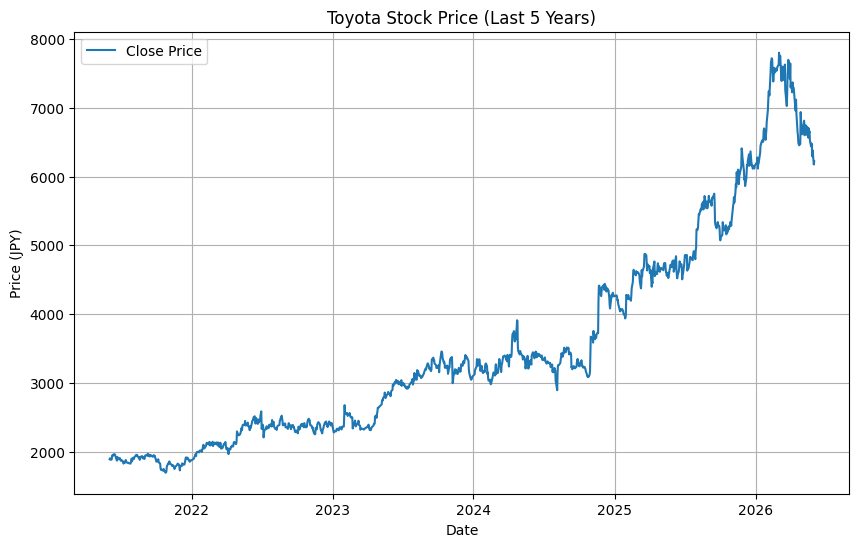

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(hist.index, hist["Close"], label="Close Price")
plt.title("Tokyo Gas Stock Price (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price (JPY)")
plt.legend()
plt.grid()
plt.show()

# info

Yahoo Financeが加工・集約した企業情報

アプリ開発Ver2は、財務に関する機能を開発する。

そのためのPoCとして、`info`で取整理する得できる情報を整理する

In [5]:
info = ticker.info
info.keys()

dict_keys(['address1', 'address2', 'city', 'zip', 'country', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'irWebsite', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'dividendRate', 'dividendYield', 'exDividendDate', 'payoutRatio', 'fiveYearAvgDividendYield', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'marketCap', 'nonDilutedMarketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 'trailingAnnualDividendRate', 'trailingAnnualDividendYield', 'currency', 'trad

In [6]:
basic_info = {
    "PER": info.get("forwardPE"),
    "PBR": info.get("priceToBook"),
    "ROE": info.get("returnOnEquity"),
    "時価総額": info.get("marketCap"),
    "配当利回り": info.get("trailingAnnualDividendYield"),
    "EPS": info.get("trailingEps"),
    "BPS": info.get("bookValue"),
}

for k, v in basic_info.items():
    print(f"{k}: {v}")

PER: 22.93595
PBR: 1.2064254
ROE: 0.12762
時価総額: 2073866665984
配当利回り: 0.017813765
EPS: 654.55
BPS: 5155.727


In [7]:
info.get("forwardPE")

22.93595

# balance_sheet

In [13]:
ticker.balance_sheet.index

Index(['Treasury Shares Number', 'Ordinary Shares Number', 'Share Issued',
       'Net Debt', 'Total Debt', 'Tangible Book Value', 'Invested Capital',
       'Working Capital', 'Net Tangible Assets', 'Common Stock Equity',
       'Total Capitalization', 'Total Equity Gross Minority Interest',
       'Minority Interest', 'Stockholders Equity', 'Treasury Stock',
       'Retained Earnings', 'Additional Paid In Capital', 'Capital Stock',
       'Common Stock', 'Total Liabilities Net Minority Interest',
       'Total Non Current Liabilities Net Minority Interest',
       'Other Non Current Liabilities',
       'Non Current Pension And Other Postretirement Benefit Plans',
       'Non Current Deferred Taxes Liabilities',
       'Long Term Debt And Capital Lease Obligation', 'Long Term Debt',
       'Long Term Provisions', 'Current Liabilities',
       'Other Current Liabilities',
       'Current Debt And Capital Lease Obligation', 'Current Debt', 'Payables',
       'Total Tax Payable', 'Accou

In [19]:
important_items = {
    "Stockholders Equity": "自己資本",
    "Total Assets": "総資産",
    "Total Debt": "有利子負債",
}

balance_sheet_summary = ticker.balance_sheet.loc[important_items.keys()]

balance_sheet_summary.index = important_items.values()

print(balance_sheet_summary)


         2025-03-31    2024-03-31    2023-03-31    2022-03-31
自己資本   1.725444e+12  1.693477e+12  1.558403e+12  1.251780e+12
総資産    3.855093e+12  3.897608e+12  3.581425e+12  3.187627e+12
有利子負債  1.308007e+12  1.343123e+12  1.242885e+12  1.172701e+12


# financials
有価証券報告書などの財務諸表由来、主に損益計算書

In [8]:
ticker.financials

,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Tax Effect Of Unusual Items,NaN,-2.333344e+09,7.943128e+09,-3.607266e+09,5.750882e+08
Tax Rate For Calcs,NaN,3.160000e-01,3.321960e-01,3.090000e-01,2.882650e-01
Normalized EBITDA,NaN,4.086480e+11,4.505810e+11,6.393670e+11,3.458950e+11
Total Unusual Items,NaN,-7.384000e+09,2.391100e+10,-1.167400e+10,1.995000e+09
Total Unusual Items Excluding Goodwill,NaN,-7.384000e+09,2.391100e+10,-1.167400e+10,1.995000e+09
Net Income From Continuing Operation Net Minority Interest,NaN,7.419400e+10,1.654810e+11,2.809160e+11,9.570200e+10
Reconciled Depreciation,NaN,2.638420e+11,2.097640e+11,2.050760e+11,1.968100e+11
Reconciled Cost Of Revenue,NaN,2.230573e+12,2.190796e+12,2.596462e+12,1.766392e+12
EBITDA,NaN,4.012640e+11,4.744920e+11,6.276930e+11,3.478900e+11
EBIT,NaN,1.374220e+11,2.647280e+11,4.226170e+11,1.510800e+11


In [9]:
ticker.financials.index

Index(['Tax Effect Of Unusual Items', 'Tax Rate For Calcs',
       'Normalized EBITDA', 'Total Unusual Items',
       'Total Unusual Items Excluding Goodwill',
       'Net Income From Continuing Operation Net Minority Interest',
       'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA',
       'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income',
       'Normalized Income',
       'Net Income From Continuing And Discontinued Operation',
       'Total Expenses', 'Total Operating Income As Reported',
       'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS',
       'Basic EPS', 'Diluted NI Availto Com Stockholders',
       'Net Income Common Stockholders', 'Otherunder Preferred Stock Dividend',
       'Net Income', 'Minority Interests',
       'Net Income Including Noncontrolling Interests',
       'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income',
       'Other Non Operating Income Expenses', 'Special Income Charges',
      

In [10]:
important_items = {
    "Total Revenue": "売上高",
    "Operating Income": "営業利益",
    "Net Income": "当期純利益",
    "Basic EPS": "EPS",
}

financials_summary = ticker.financials.loc[important_items.keys()]

financials_summary.index = important_items.values()

print(financials_summary)

       2026-03-31    2025-03-31    2024-03-31    2023-03-31    2022-03-31
売上高           NaN  2.636809e+12  2.662420e+12  3.289634e+12  2.154860e+12
営業利益          NaN  1.330910e+11  2.171440e+11  4.214770e+11  1.275260e+11
当期純利益         NaN  7.419400e+10  1.654810e+11  2.809160e+11  9.570200e+10
EPS        654.76  1.922200e+02  4.118800e+02  6.469900e+02           NaN


# others

In [11]:
ticker.dividends.tail()

Date
2024-03-28 00:00:00+09:00    37.5
2024-09-27 00:00:00+09:00    35.0
2025-03-28 00:00:00+09:00    45.0
2025-09-29 00:00:00+09:00    50.0
2026-03-30 00:00:00+09:00    60.0
Name: Dividends, dtype: float64

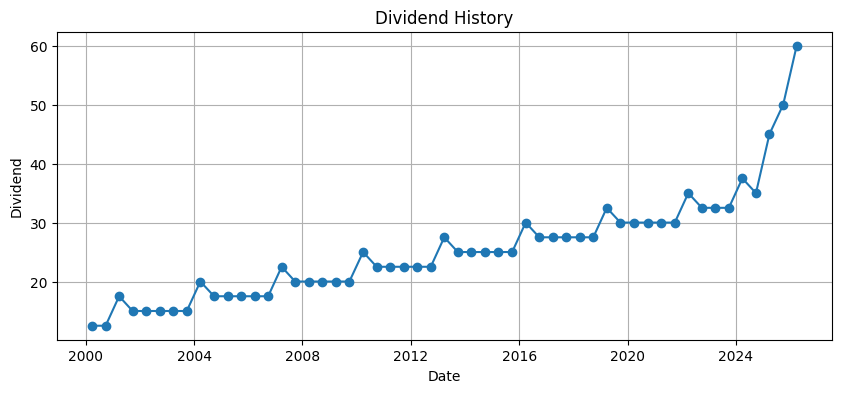

In [ ]:
dividends = ticker.dividends

plt.figure(figsize=(10, 4))

plt.plot(dividends.index, dividends.values, marker="o")

plt.title("Dividend History")
plt.xlabel("Date")
plt.ylabel("Dividend")
plt.grid(True)

plt.show()